In [1]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001E0FB4CD090> [0]

In [3]:
REGION = 'ExtNord'
YEAR = 2025

In [ ]:
#timeline_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_filled_cleaned.csv', encoding=enc)

In [4]:
timeline_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_08_filled_cleaned.csv', encoding=enc)

In [5]:
try:
    timeline_file.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

In [6]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15339.0,NaN,0.00
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-02,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15339.0,NaN,0.11
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-03,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15299.0,14601.0,1.25
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-04,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15431.0,14619.0,0.66
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-05,2025,1,0.231400,-0.144919,-0.319074,0.144919,0.229307,-0.145684,-0.323623,0.145684,0.008093,0.013163,0.007198,0.013163,15179.0,14588.0,0.39


In [7]:
print(f'Shape of the timeline file: {timeline_file.shape}')

Shape of the timeline file: (503253, 24)


Text(0.5, 1.0, 'Year: 2025')

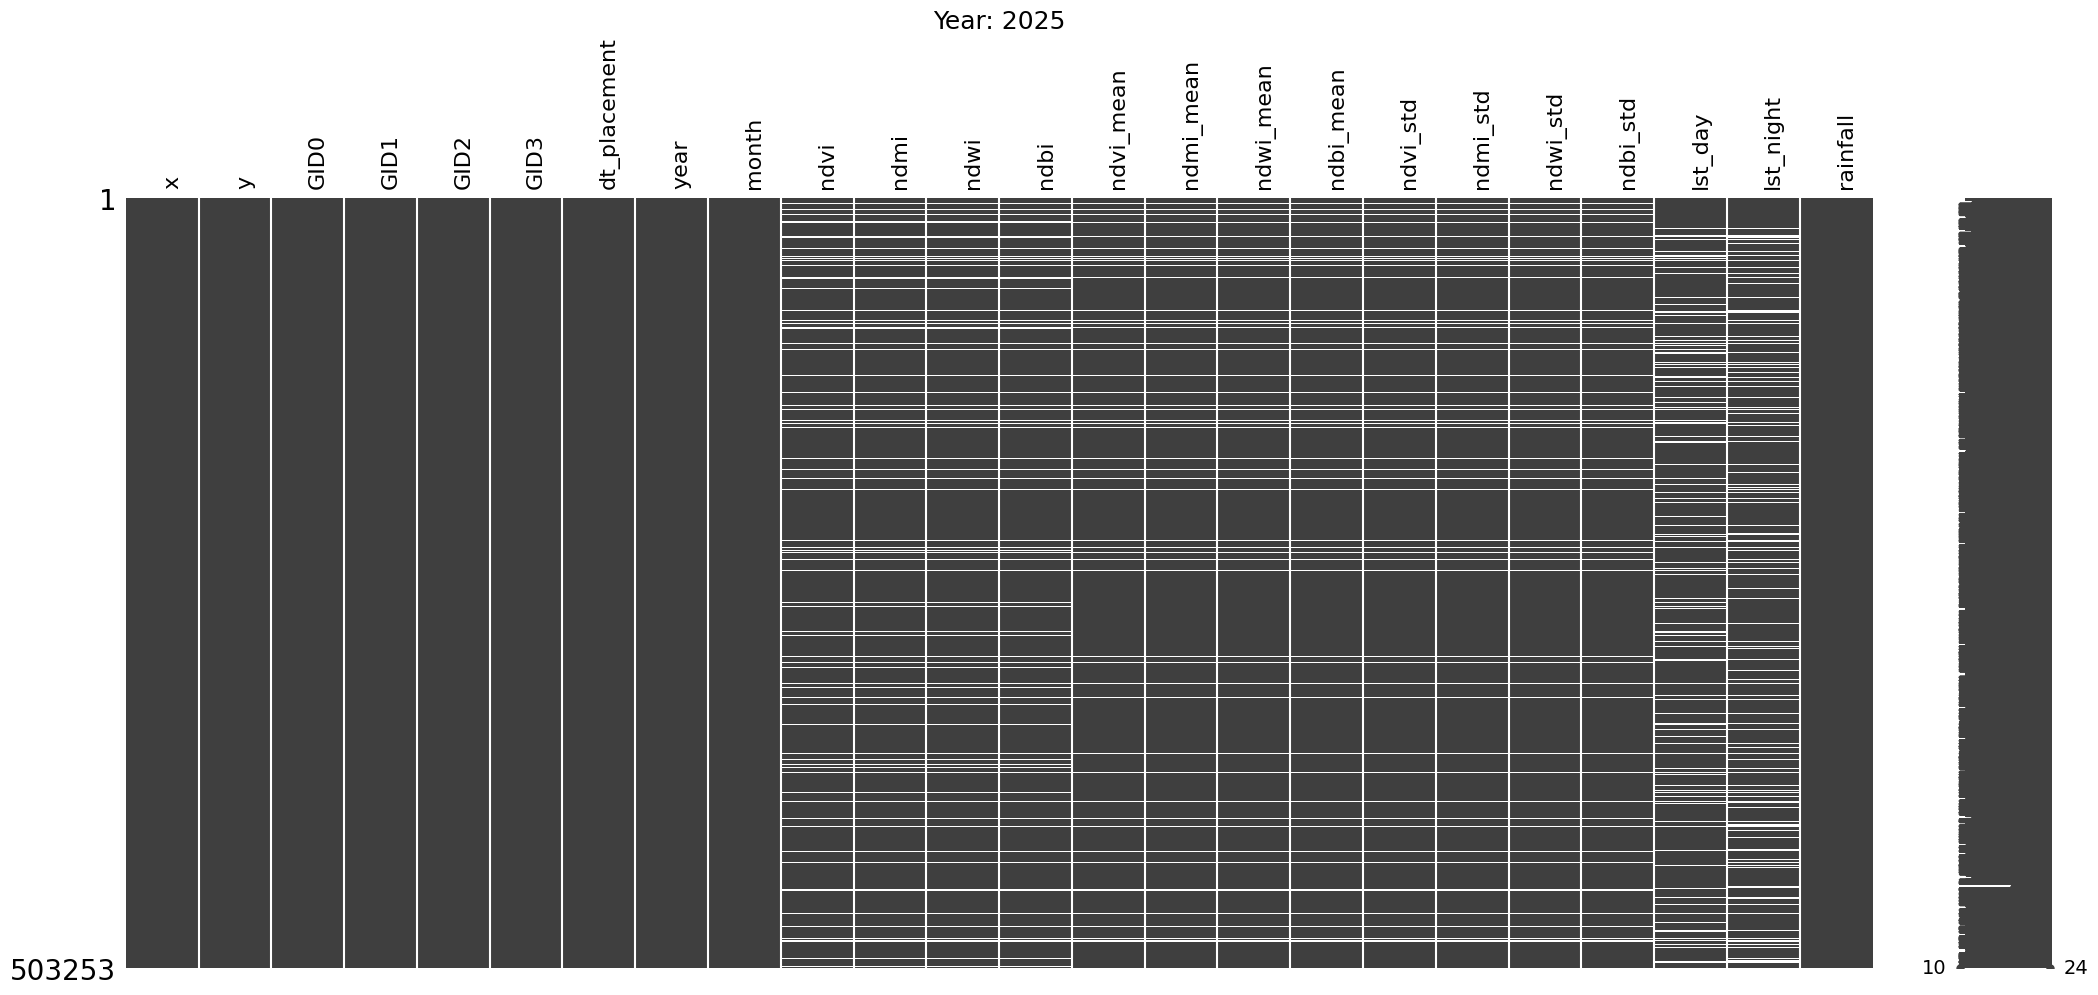

In [8]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2

In [10]:
timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [11]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15339.0,NaN,0.00,NaN,0.5,0.866
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-02,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15339.0,NaN,0.11,NaN,0.5,0.866
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-03,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15299.0,14601.0,1.25,14950.0,0.5,0.866
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-04,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15431.0,14619.0,0.66,15025.0,0.5,0.866
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-05,2025,1,0.231400,-0.144919,-0.319074,0.144919,0.229307,-0.145684,-0.323623,0.145684,0.008093,0.013163,0.007198,0.013163,15179.0,14588.0,0.39,14883.5,0.5,0.866


In [12]:
geomorphological = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Geomorphological.csv', encoding=enc)
geomorphological.columns = geomorphological.columns.str.lower()
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,14.40633,10.67157,53835.186164,422.470201,0,148.095638,374.813768,179.773696,0.0,1.265235
1,14.44281,10.67157,50119.456676,940.674765,1,144.625249,367.554596,179.818437,0.0,4.407546
2,14.44281,10.70751,48754.919418,1750.252886,3,180.563395,363.746116,179.765555,0.0,3.276963
3,14.44281,10.74344,47681.360299,697.440407,1,127.677798,358.113702,179.643406,0.0,1.867835
4,14.47929,10.70751,44973.961290,1045.737685,5,150.000751,358.118988,179.967877,0.0,1.000000


In [13]:
geomorphological['x_rounded'] = geomorphological['x'].round(4)
geomorphological['y_rounded'] = geomorphological['y'].round(4)

geomorphological.drop(columns=['x', 'y'], inplace=True)

timeline_file['x_rounded'] = timeline_file['x'].round(4)
timeline_file['y_rounded'] = timeline_file['y'].round(4)

timeline_file = pd.merge(timeline_file, geomorphological, on=['x_rounded', 'y_rounded'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15339.0,NaN,0.00,NaN,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-02,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15339.0,NaN,0.11,NaN,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-03,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15299.0,14601.0,1.25,14950.0,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-04,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15431.0,14619.0,0.66,15025.0,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-05,2025,1,0.231400,-0.144919,-0.319074,0.144919,0.229307,-0.145684,-0.323623,0.145684,0.008093,0.013163,0.007198,0.013163,15179.0,14588.0,0.39,14883.5,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908


Text(0.5, 1.0, 'Year: 2025')

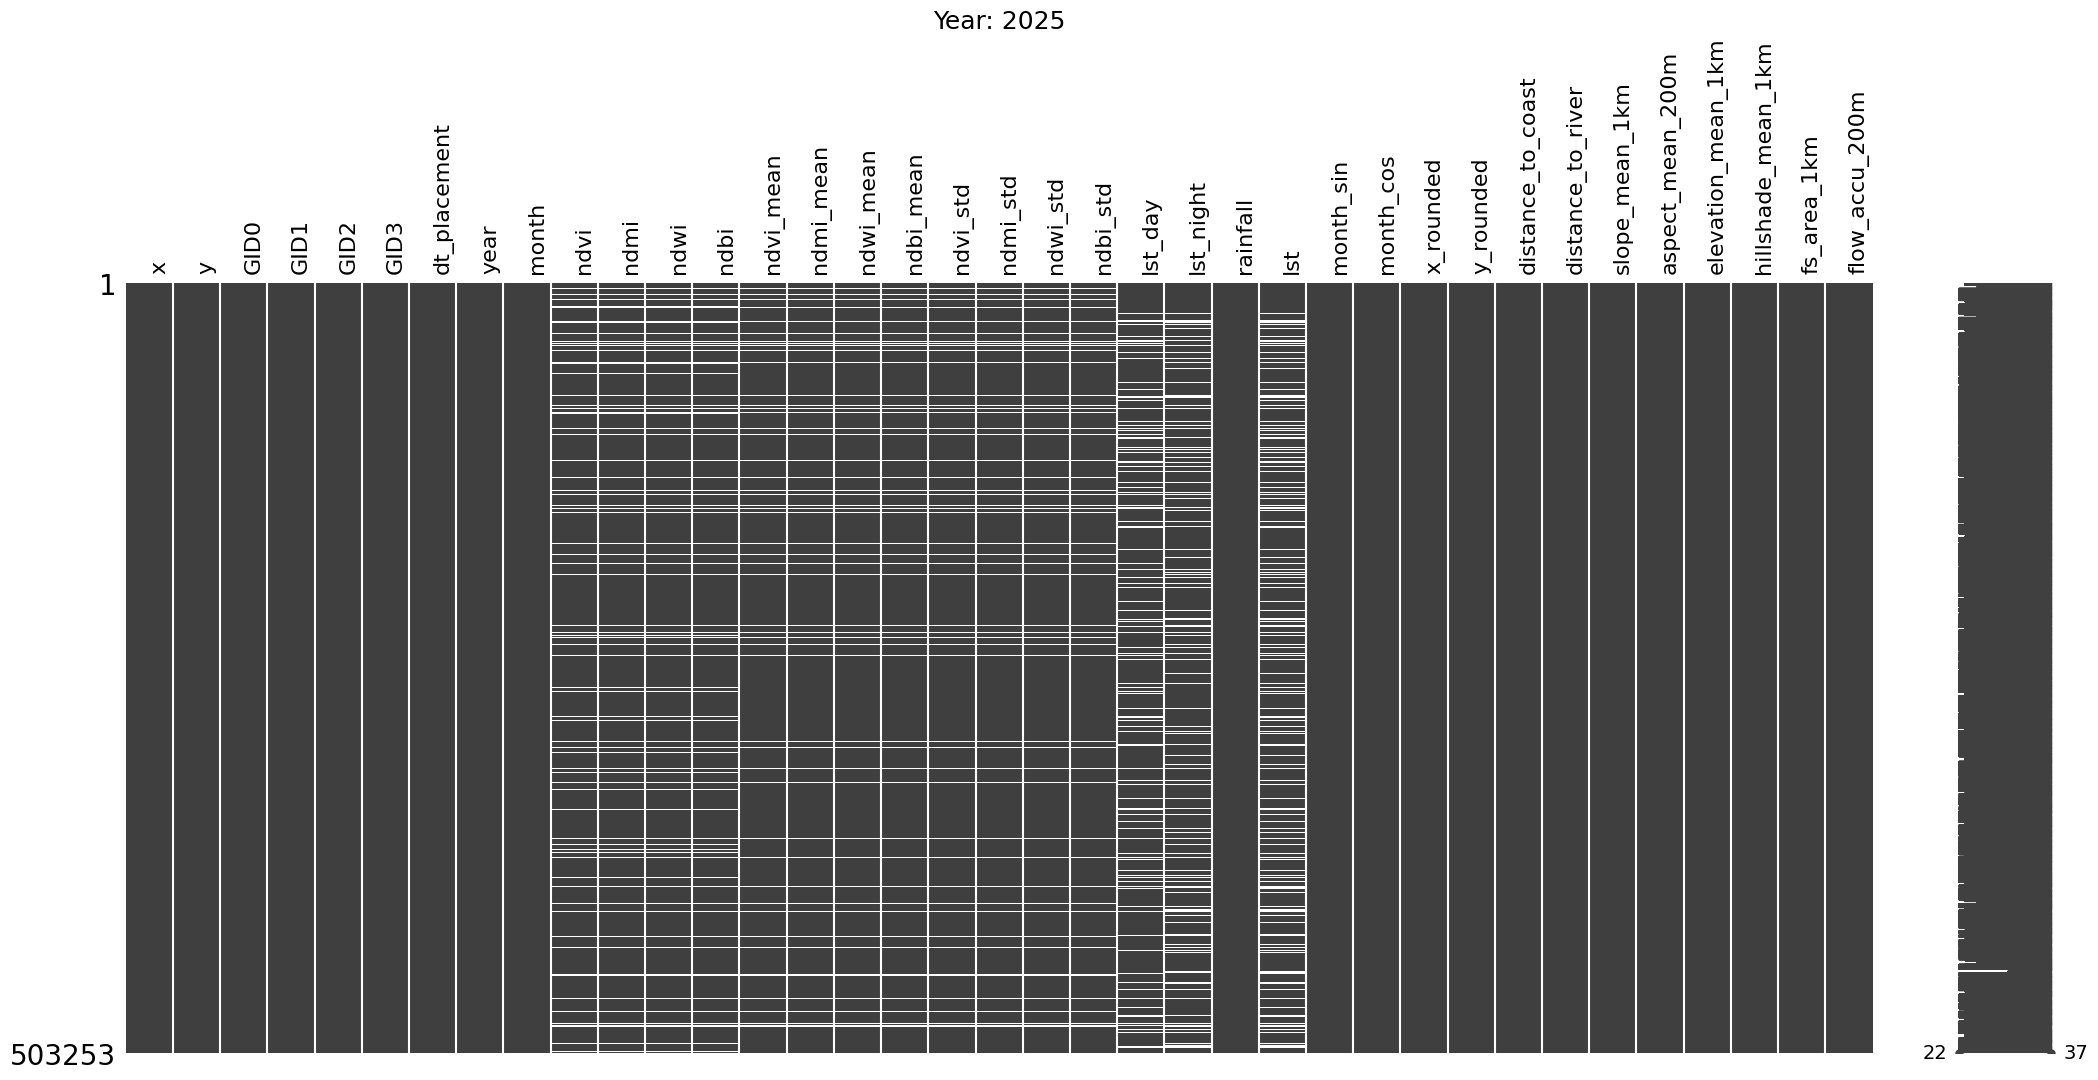

In [14]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [15]:
landcover = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Landcover_2001-2024_processed.csv')
landcover = landcover[landcover['year'] == YEAR - 1].copy()
landcover.head()

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
47633,14.40633,10.67157,2024,31,99,36,99.0,30,99,12,12,1,6,7,2,0
47634,14.44281,10.67157,2024,31,99,36,99.0,30,99,12,12,1,6,7,2,0
47635,14.44281,10.70751,2024,31,99,36,99.0,30,99,12,12,1,6,7,2,0
47636,14.44281,10.74344,2024,31,99,36,99.0,30,99,12,12,1,6,7,2,0
47637,14.47929,10.70751,2024,31,99,36,99.0,30,99,12,12,1,6,7,2,0


In [16]:
landcover['x_rounded'] = landcover['x'].round(4)
landcover['y_rounded'] = landcover['y'].round(4)
landcover.rename(columns={'year': 'year_lc'}, inplace=True)
landcover.drop(columns=['x', 'y'], inplace=True)

timeline_file['year_lc'] = timeline_file['year'] - 1

In [17]:
timeline_file = pd.merge(timeline_file, landcover, on=['x_rounded', 'y_rounded', 'year_lc'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15339.0,NaN,0.00,NaN,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2024,31,98,36,98.0,30,98,12,12,3,5,8,2,0
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-02,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15339.0,NaN,0.11,NaN,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2024,31,98,36,98.0,30,98,12,12,3,5,8,2,0
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-03,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15299.0,14601.0,1.25,14950.0,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2024,31,98,36,98.0,30,98,12,12,3,5,8,2,0
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-04,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15431.0,14619.0,0.66,15025.0,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2024,31,98,36,98.0,30,98,12,12,3,5,8,2,0
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-05,2025,1,0.231400,-0.144919,-0.319074,0.144919,0.229307,-0.145684,-0.323623,0.145684,0.008093,0.013163,0.007198,0.013163,15179.0,14588.0,0.39,14883.5,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2024,31,98,36,98.0,30,98,12,12,3,5,8,2,0


In [18]:
timeline_file.loc[timeline_file['lc_prop1_assessment'] < 80, 'lc_prop1'] = np.nan
timeline_file.loc[timeline_file['lc_prop2_assessment'] < 80, 'lc_prop2'] = np.nan
timeline_file.loc[timeline_file['lc_prop3_assessment'] < 80, 'lc_prop3'] = np.nan

In [19]:
timeline_file.drop(columns=['x_rounded', 'y_rounded', 'lc_prop1_assessment', 'lc_prop2_assessment', 'lc_prop3_assessment', 'lw', 'qc'], inplace=True)

Text(0.5, 1.0, 'Year: 2025')

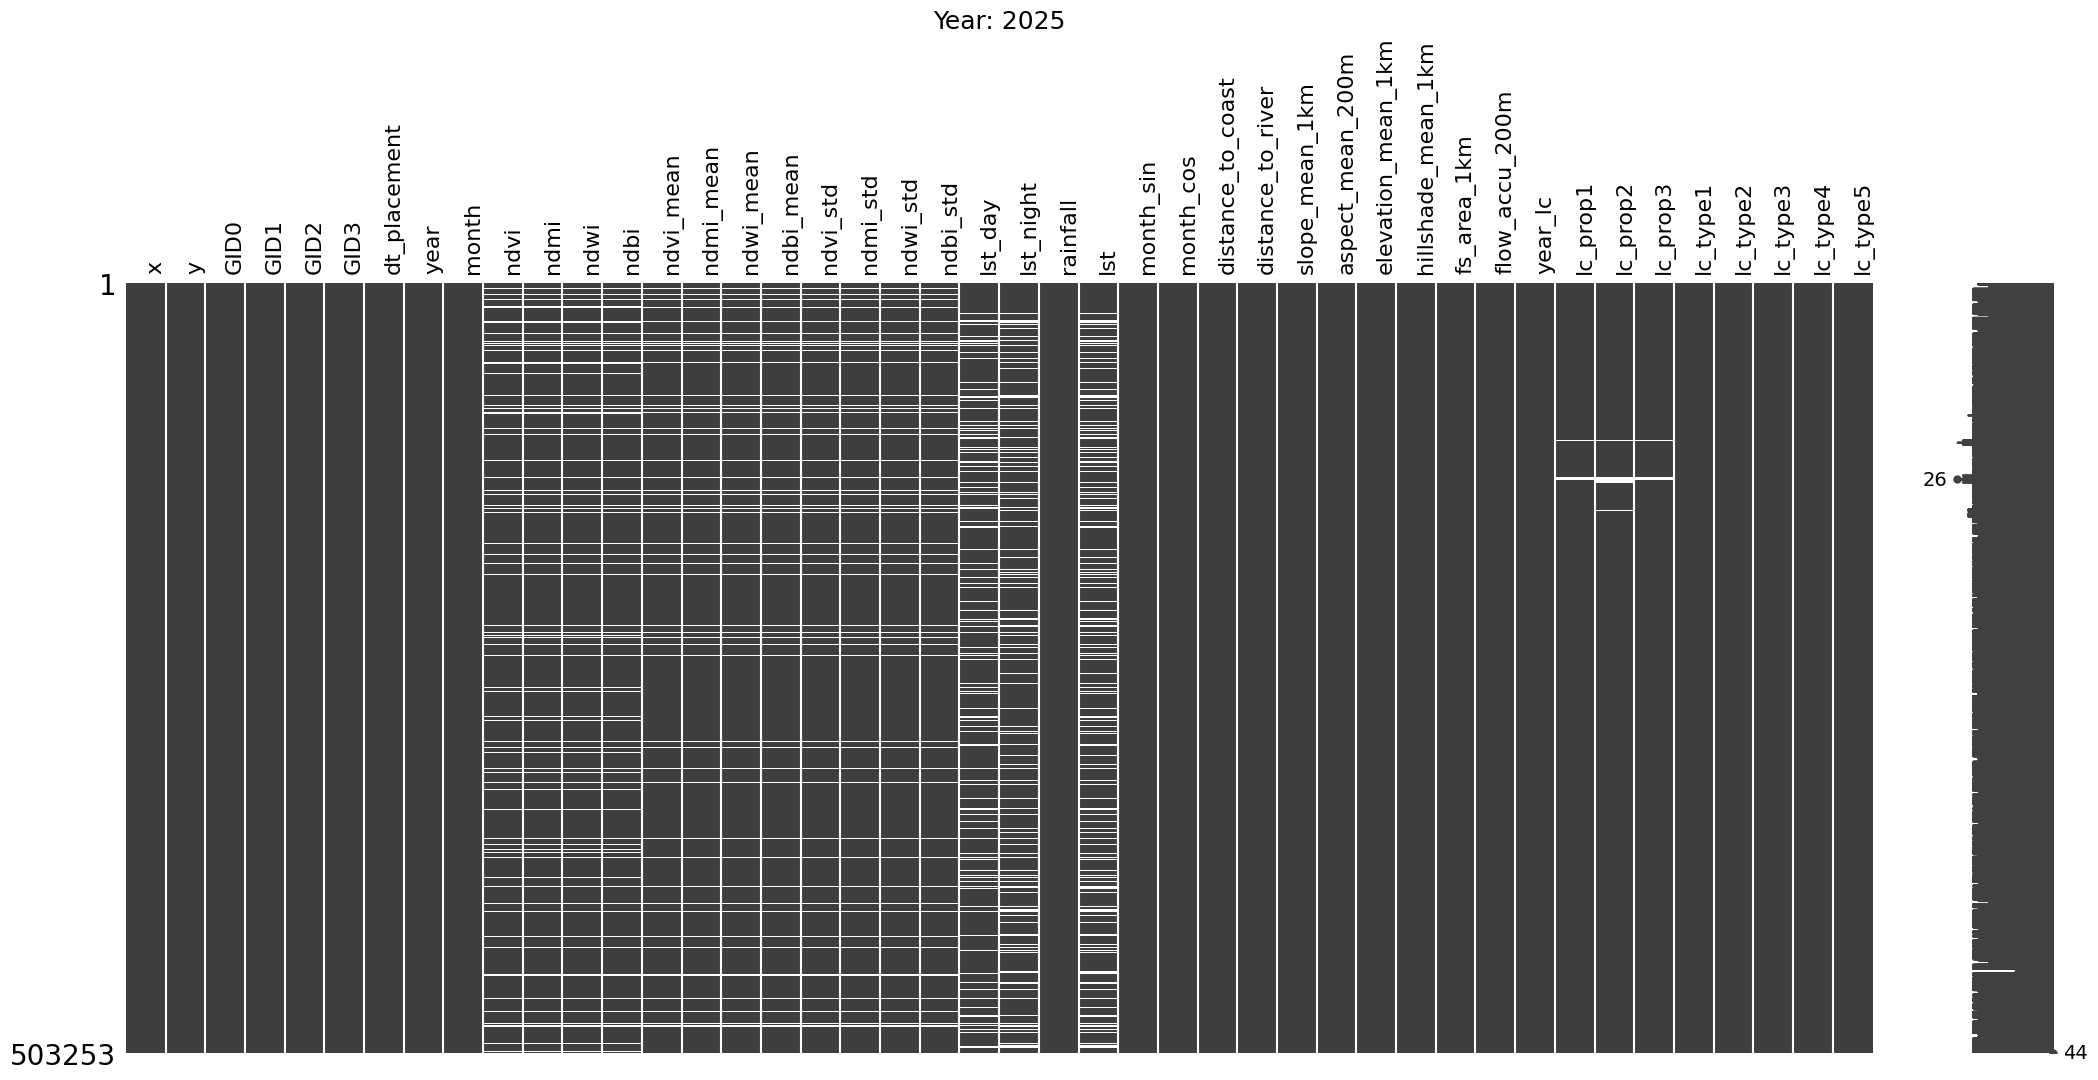

In [20]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [21]:
timeline_file

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15339.0,NaN,0.00,NaN,0.500,0.866,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2024,31.0,36.0,30.0,12,12,3,5,8
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-02,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15339.0,NaN,0.11,NaN,0.500,0.866,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2024,31.0,36.0,30.0,12,12,3,5,8
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-03,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15299.0,14601.0,1.25,14950.0,0.500,0.866,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2024,31.0,36.0,30.0,12,12,3,5,8
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-04,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15431.0,14619.0,0.66,15025.0,0.500,0.866,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2024,31.0,36.0,30.0,12,12,3,5,8
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-05,2025,1,0.231400,-0.144919,-0.319074,0.144919,0.229307,-0.145684,-0.323623,0.145684,0.008093,0.013163,0.007198,0.013163,15179.0,14588.0,0.39,14883.5,0.500,0.866,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2024,31.0,36.0,30.0,12,12,3,5,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503248,15.57371,10.02477,extreme nord,mayo-danay,guere,nouldaina,2025-08-27,2025,8,0.546955,0.172618,-0.419604,-0.172618,0.435715,0.222549,-0.328320,-0.222549,0.062261,0.067652,0.066262,0.067652,NaN,NaN,0.00,NaN,-0.866,-0.500,15129.198590,2078.187034,4,144.211093,332.888659,180.274922,0.0,5.192344,2024,31.0,36.0,30.0,12,12,1,6,7
503249,15.57371,10.02477,extreme nord,mayo-danay,guere,nouldaina,2025-08-28,2025,8,0.552310,0.267328,-0.216691,-0.267328,0.557122,0.306295,-0.179481,-0.306295,0.060035,0.023811,0.061219,0.023811,NaN,NaN,0.00,NaN,-0.866,-0.500,15129.198590,2078.187034,4,144.211093,332.888659,180.274922,0.0,5.192344,2024,31.0,36.0,30.0,12,12,1,6,7
503250,15.57371,10.02477,extreme nord,mayo-danay,guere,nouldaina,2025-08-29,2025,8,0.552310,0.267328,-0.216691,-0.267328,0.557122,0.306295,-0.179481,-0.306295,0.060035,0.023811,0.061219,0.023811,NaN,NaN,0.35,NaN,-0.866,-0.500,15129.198590,2078.187034,4,144.211093,332.888659,180.274922,0.0,5.192344,2024,31.0,36.0,30.0,12,12,1,6,7
503251,15.57371,10.02477,extreme nord,mayo-danay,guere,nouldaina,2025-08-30,2025,8,0.534420,0.169878,-0.407995,-0.169878,0.496937,0.183577,-0.379802,-0.183577,0.041321,0.038749,0.039112,0.038749,NaN,NaN,2.30,NaN,-0.866,-0.500,15129.198590,2078.187034,4,144.211093,332.888659,180.274922,0.0,5.192344,2024,31.0,36.0,30.0,12,12,1,6,7


In [22]:
gid_unit_counts = []

for gid_unit in timeline_file.GID3.sort_values().unique().tolist():
    count = (timeline_file['GID3'] == gid_unit).sum()
    gid_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_unit_counts_df = pd.DataFrame(gid_unit_counts)

In [23]:
fig = px.bar(gid_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [24]:
group_cols = ['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3']
mode_cols = ['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5']
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']

grouped_by_gid3 = timeline_file.groupby(group_cols, as_index = False)

grouped_by_gid3_mean = grouped_by_gid3.mean()
grouped_by_gid3_std = grouped_by_gid3.std()

grouped_by_gid3_most_common = timeline_file[group_cols].drop_duplicates()

for col in mode_cols:
    mode_series = (timeline_file.groupby(group_cols)[col].value_counts().groupby(level=group_cols).idxmax().apply(lambda x: x[-1]).reset_index(name=col))
    grouped_by_gid3_most_common = grouped_by_gid3_most_common.merge(mode_series, on=group_cols, how='left')


In [25]:
grouped_by_gid3_mean.drop(columns = mode_cols, inplace=True)
grouped_by_gid3_std = grouped_by_gid3_std[group_cols + geo_cols].copy()
grouped_by_gid3_std.columns = group_cols + [f"{col}_std" for col in geo_cols]

In [26]:
grouped_by_gid3 = grouped_by_gid3_mean.merge(grouped_by_gid3_std, on=group_cols, how='left')
grouped_by_gid3 = grouped_by_gid3.merge(grouped_by_gid3_most_common, on=group_cols, how='left')

In [27]:
print(f'Shape of the grouped_by_gid3 file: {grouped_by_gid3.shape}')

Shape of the grouped_by_gid3 file: (77031, 52)


Text(0.5, 1.0, 'Year: 2025.0')

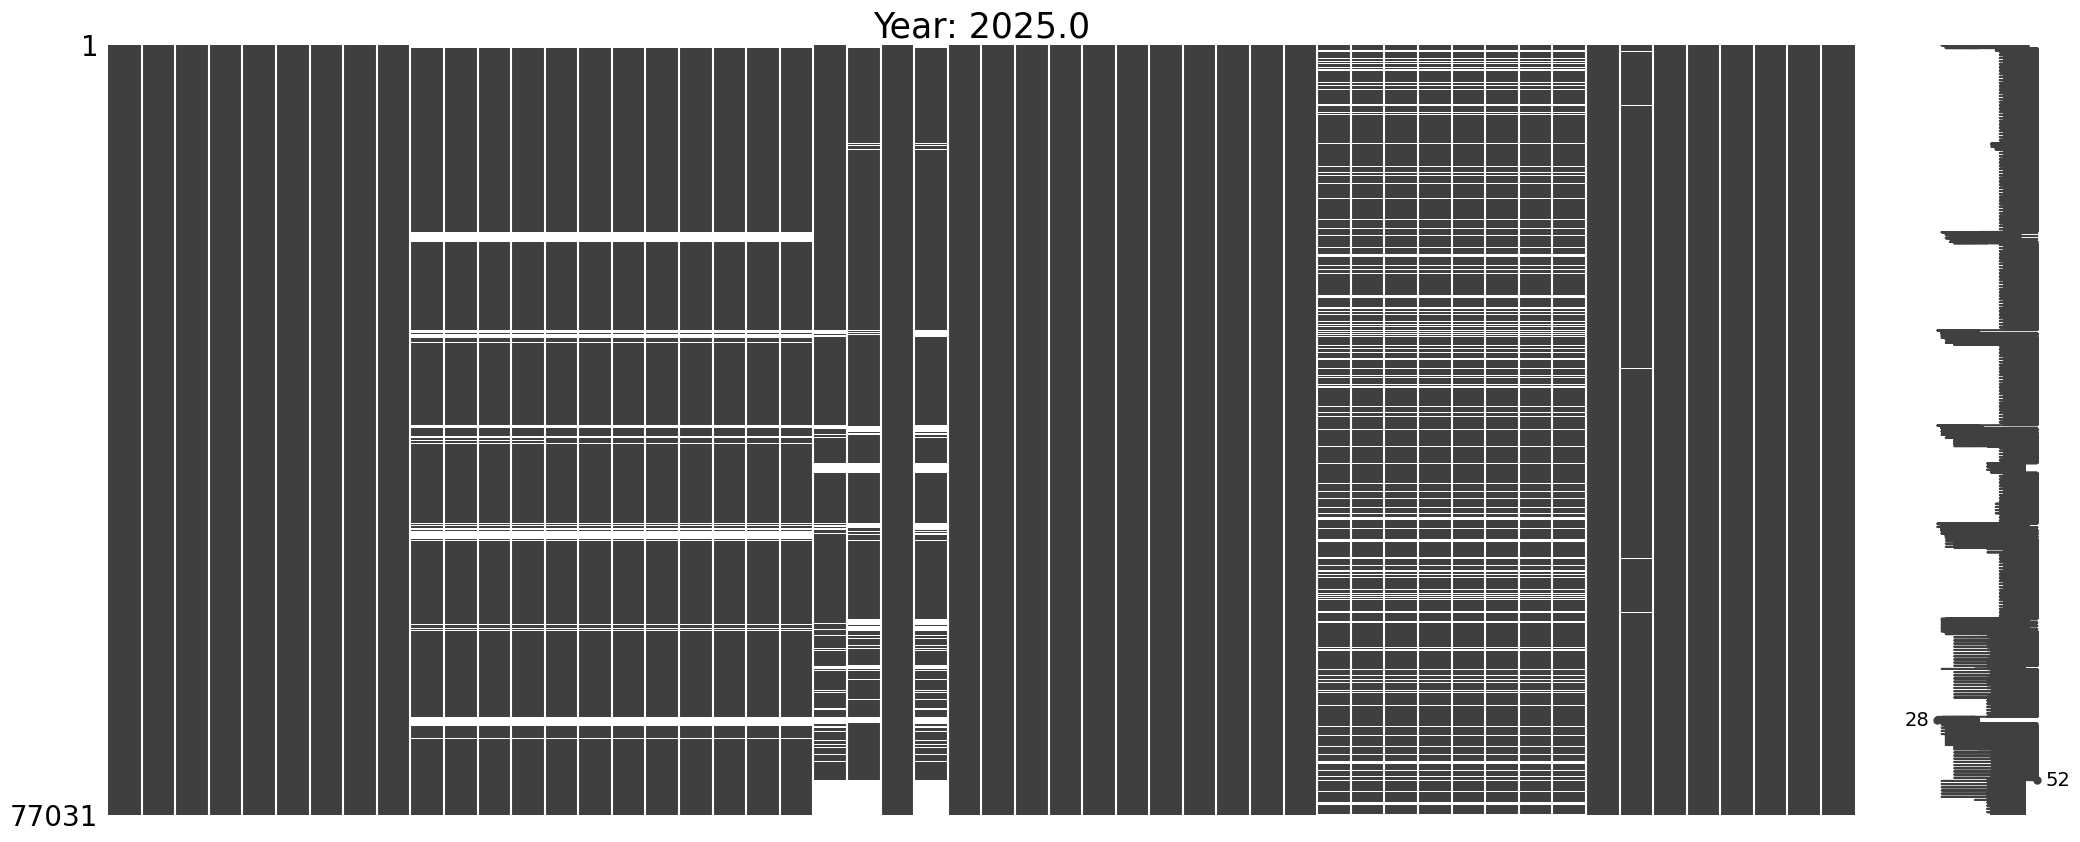

In [28]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=25)

In [29]:
gid_mean_unit_counts = []

for gid_unit in grouped_by_gid3.GID3.sort_values().unique().tolist():
    count = (grouped_by_gid3['GID3'] == gid_unit).sum()
    gid_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_mean_unit_counts_df = pd.DataFrame(gid_mean_unit_counts)

In [30]:
fig = px.bar(gid_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [31]:
grouped_by_gid3 = convert_temperature(grouped_by_gid3)

In [32]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2025-01-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2025.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.299333,NaN,0.0,NaN,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2024.0,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12,12,1,6,7
1,2025-01-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2025.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.538571,NaN,0.0,NaN,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2024.0,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12,12,1,6,7
2,2025-01-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2025.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.015000,NaN,0.0,NaN,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2024.0,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12,12,1,6,7
3,2025-01-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2025.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.956667,NaN,0.0,NaN,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2024.0,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12,12,1,6,7
4,2025-01-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2025.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.455000,NaN,0.0,NaN,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2024.0,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12,12,1,6,7


In [33]:
grouped_by_gid3['year'] = grouped_by_gid3['year'].astype(int)
grouped_by_gid3['year_lc'] = grouped_by_gid3['year_lc'].astype(int)
grouped_by_gid3['month'] = grouped_by_gid3['month'].astype(int)

In [34]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2025-01-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.299333,NaN,0.0,NaN,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2024,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12,12,1,6,7
1,2025-01-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.538571,NaN,0.0,NaN,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2024,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12,12,1,6,7
2,2025-01-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.015000,NaN,0.0,NaN,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2024,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12,12,1,6,7
3,2025-01-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.956667,NaN,0.0,NaN,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2024,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12,12,1,6,7
4,2025-01-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.455000,NaN,0.0,NaN,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2024,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12,12,1,6,7


Text(0.5, 1.0, 'Year: 2025')

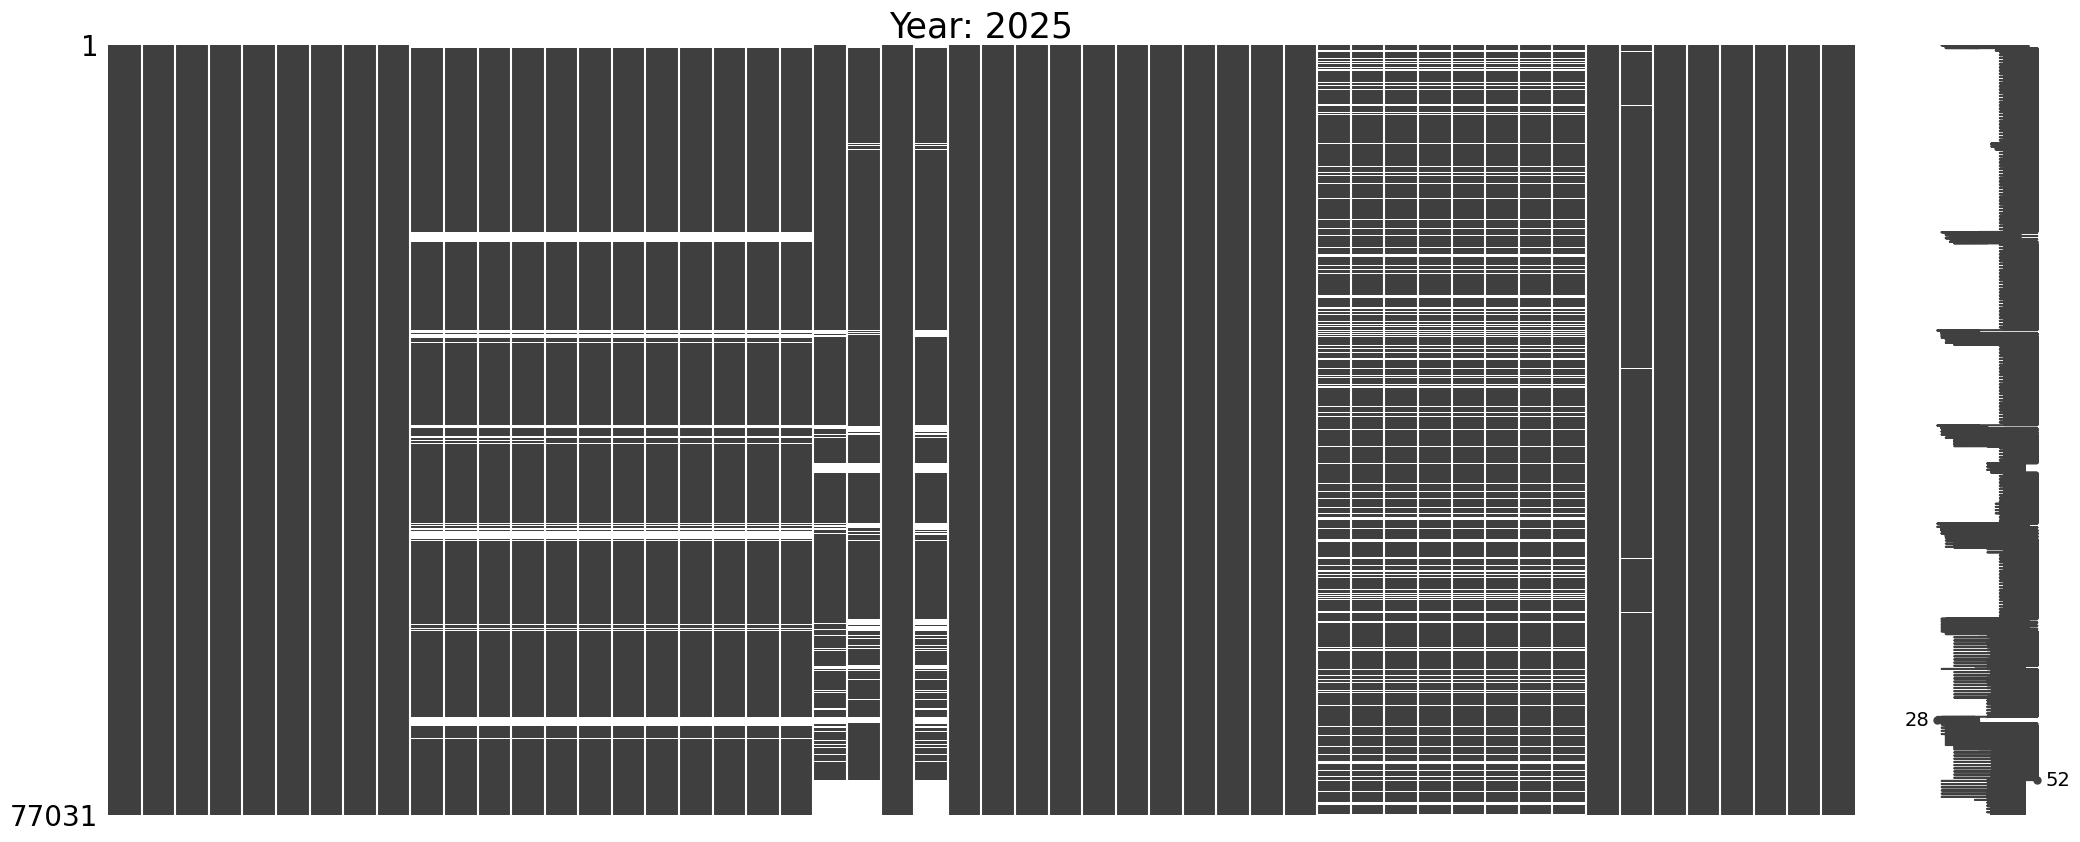

In [35]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=25)

In [36]:
# Group by the needed dimensions
grouped_mask = grouped_by_gid3.groupby(['GID2', 'GID3', 'year', 'month'])

# Compute the min and max temperature across lst_day and lst_night
monthly_lst_min = grouped_mask[['lst_day', 'lst_night']].min().min(axis=1)
monthly_lst_max = grouped_mask[['lst_day', 'lst_night']].max().max(axis=1)

# Compute total precipitation
monthly_rainfall_acc = grouped_mask['rainfall'].sum()

# Combine results into a single DataFrame
min_max_acc_weather_df = pd.DataFrame({
    'monthly_lst_min': monthly_lst_min,
    'monthly_lst_max': monthly_lst_max,
    'monthly_rainfall_acc': monthly_rainfall_acc
}).reset_index()

In [37]:
min_max_acc_weather_df

,GID2,GID3,year,month,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,bogo,balaza,2025,1,17.011333,37.255333,0.171333
1,bogo,balaza,2025,2,16.606000,38.714000,1.558667
2,bogo,balaza,2025,3,18.517500,47.043333,0.139333
3,bogo,balaza,2025,4,21.733333,47.728667,19.545333
4,bogo,balaza,2025,5,22.663333,48.246000,10.146667
...,...,...,...,...,...,...,...
2531,yagoua,yagoua,2025,4,20.316154,47.045385,37.319999
2532,yagoua,yagoua,2025,5,19.720000,43.613077,4.713846
2533,yagoua,yagoua,2025,6,22.719231,36.788462,183.720765
2534,yagoua,yagoua,2025,7,24.300000,33.270000,105.731536


In [38]:
dataset = pd.merge(grouped_by_gid3, min_max_acc_weather_df, on=['GID2', 'GID3', 'year', 'month'], how='left')

In [39]:
dataset.head()


,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2025-01-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.299333,NaN,0.0,NaN,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2024,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12,12,1,6,7,17.011333,37.255333,0.171333
1,2025-01-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.538571,NaN,0.0,NaN,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2024,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12,12,1,6,7,16.961429,38.105238,0.056190
2,2025-01-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.015000,NaN,0.0,NaN,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2024,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12,12,1,6,7,16.740000,36.850000,0.410000
3,2025-01-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.956667,NaN,0.0,NaN,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2024,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12,12,1,6,7,16.280000,36.190000,0.063333
4,2025-01-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.455000,NaN,0.0,NaN,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2024,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12,12,1,6,7,16.627500,37.350000,0.246250


Text(0.5, 1.0, 'Year: 2025')

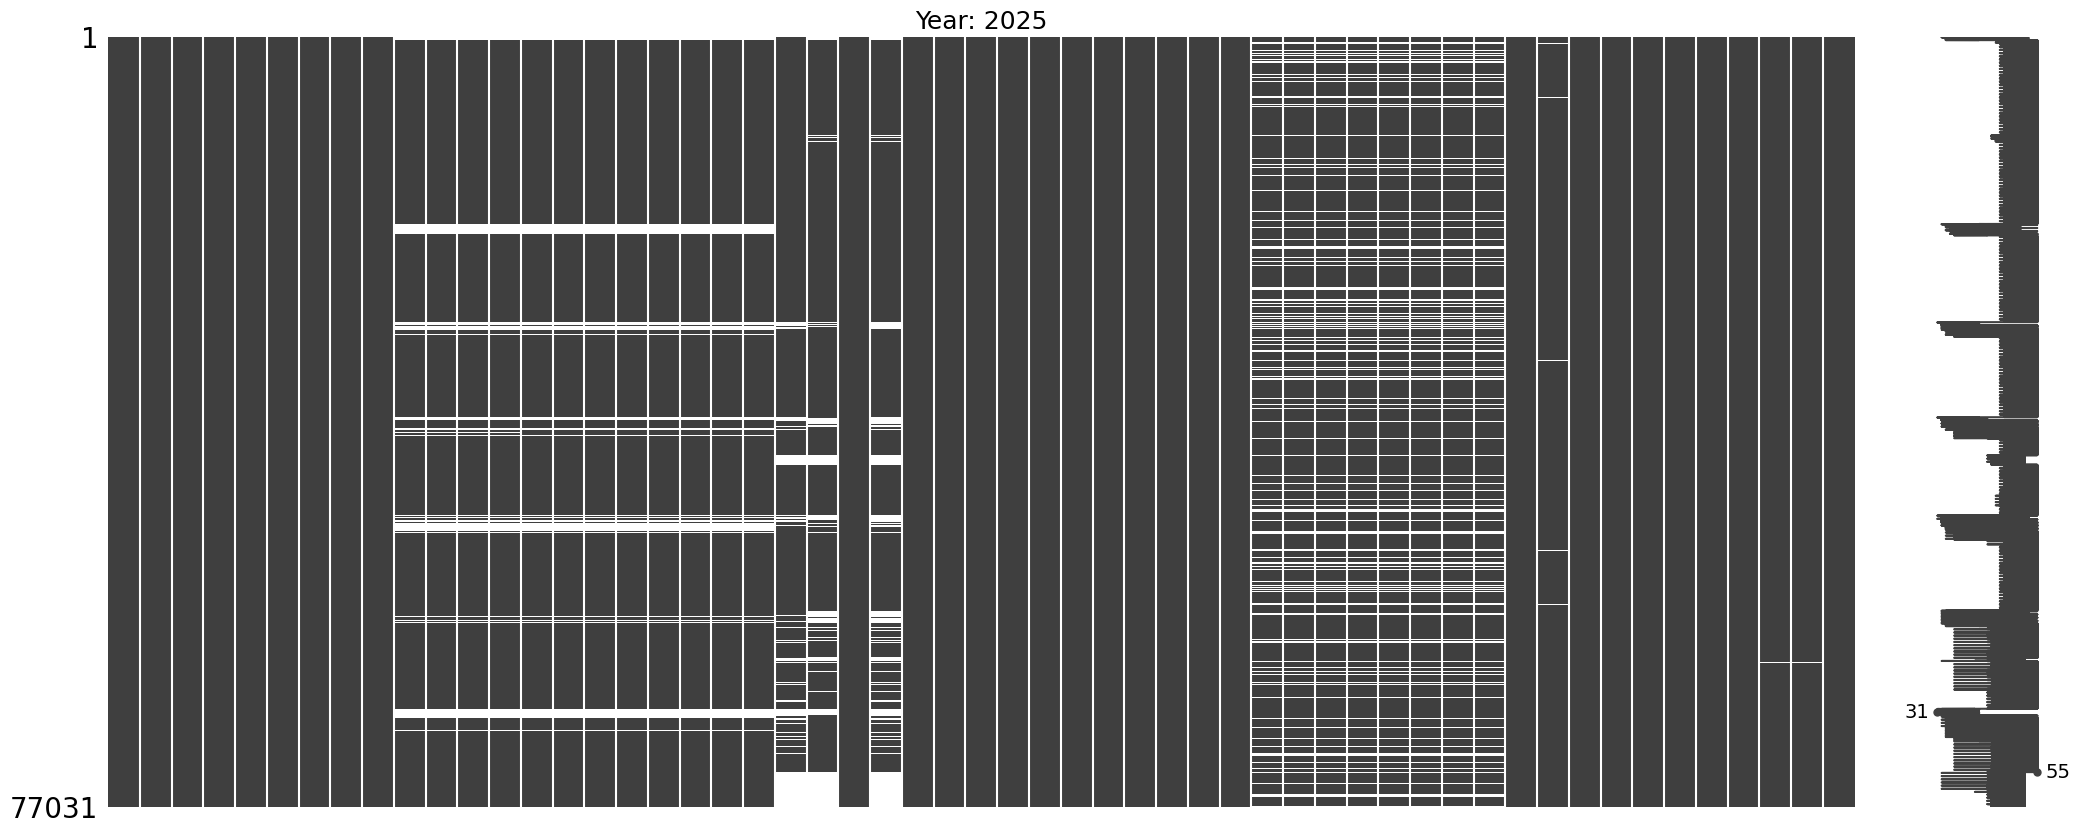

In [40]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [41]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [42]:
dataset.head()

,dt_placement_daily,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,dt_placement
0,2025-01-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.299333,NaN,0.0,NaN,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2024,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12,12,1,6,7,17.011333,37.255333,0.171333,2025-01
1,2025-01-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.538571,NaN,0.0,NaN,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2024,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12,12,1,6,7,16.961429,38.105238,0.056190,2025-01
2,2025-01-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.015000,NaN,0.0,NaN,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2024,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12,12,1,6,7,16.740000,36.850000,0.410000,2025-01
3,2025-01-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.956667,NaN,0.0,NaN,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2024,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12,12,1,6,7,16.280000,36.190000,0.063333,2025-01
4,2025-01-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.455000,NaN,0.0,NaN,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2024,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12,12,1,6,7,16.627500,37.350000,0.246250,2025-01


In [43]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement','GID0','GID1','GID2','GID3'], as_index = False)

In [44]:
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_sum = grouped_by_month.sum()

In [45]:
grouped_by_month_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2025-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2025.0,1.0,0.228613,-0.128800,-0.339775,0.128800,0.235684,-0.126217,-0.337048,0.126217,0.024453,0.023984,0.021800,0.023984,32.466860,19.064044,0.005527,25.718244,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2024.0,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,17.011333,37.255333,0.171333
1,2025-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2025.0,1.0,0.228112,-0.152122,-0.314715,0.152122,0.226544,-0.148953,-0.316381,0.148953,0.018588,0.017084,0.013574,0.017084,33.346866,19.336222,0.001813,26.288349,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2024.0,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.961429,38.105238,0.056190
2,2025-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2025.0,1.0,0.217678,-0.121785,-0.326881,0.121785,0.219530,-0.117612,-0.334587,0.117612,0.017830,0.014757,0.010896,0.014757,32.297742,19.414833,0.013226,25.811000,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2024.0,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.740000,36.850000,0.410000
3,2025-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2025.0,1.0,0.240727,-0.127691,-0.327832,0.127691,0.245421,-0.126230,-0.330774,0.126230,0.017786,0.014073,0.014566,0.014073,31.538280,18.967889,0.002043,25.212778,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2024.0,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.280000,36.190000,0.063333
4,2025-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2025.0,1.0,0.226639,-0.112302,-0.340948,0.112302,0.227393,-0.115807,-0.333396,0.115807,0.027435,0.024860,0.021228,0.024860,32.709274,19.470833,0.007944,26.044292,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2024.0,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.627500,37.350000,0.246250


In [46]:
print(f'Shape of the grouped_by_month_mean file: {grouped_by_month_mean.shape}')

Shape of the grouped_by_month_mean file: (2536, 55)


Text(0.5, 1.0, 'Year: 2025.0')

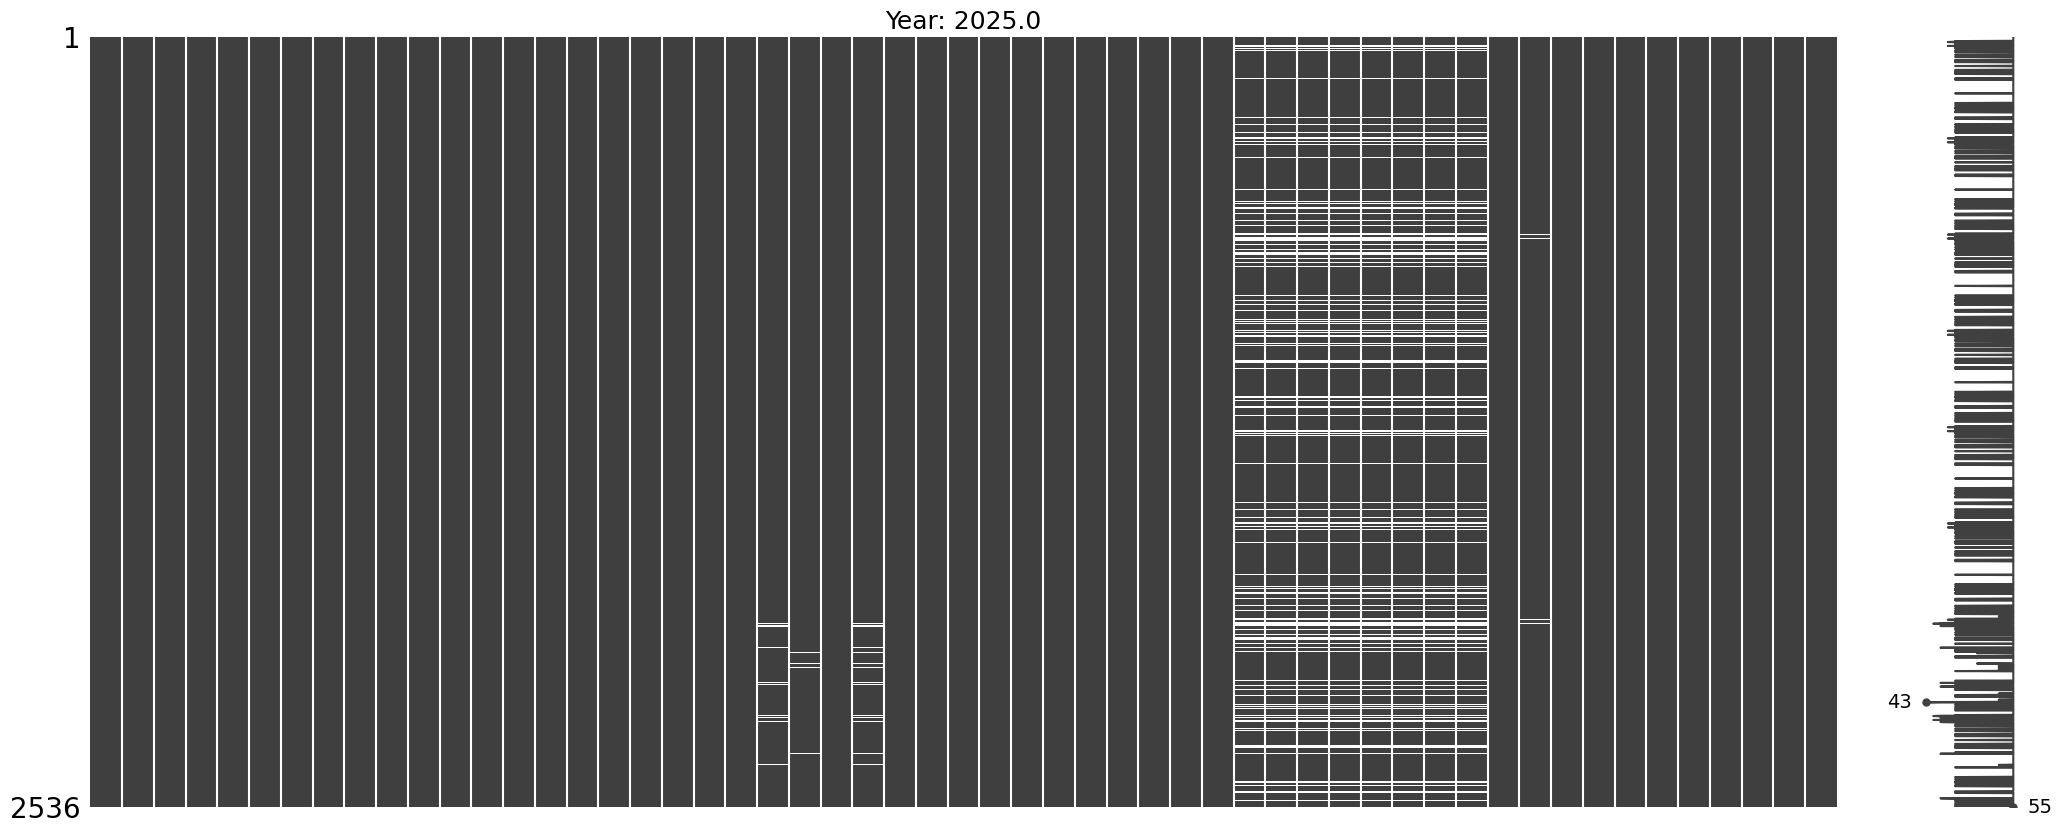

In [47]:
msno.matrix(grouped_by_month_mean, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_month_mean.year.iloc[0]}", fontsize=18)

In [48]:
month_mean_unit_counts = []

for gid_unit in grouped_by_month_mean.GID3.sort_values().unique().tolist():
    count = (grouped_by_month_mean['GID3'] == gid_unit).sum()
    month_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

month_mean_unit_counts_df = pd.DataFrame(month_mean_unit_counts)

In [49]:
fig = px.bar(month_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [50]:
grouped_by_month_mean['year'] = grouped_by_month_mean['year'].astype(int)
grouped_by_month_mean['year_lc'] = grouped_by_month_mean['year_lc'].astype(int)
grouped_by_month_mean['month'] = grouped_by_month_mean['month'].astype(int)

In [51]:
grouped_by_month_mean

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2025-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2025,1,0.228613,-0.128800,-0.339775,0.128800,0.235684,-0.126217,-0.337048,0.126217,0.024453,0.023984,0.021800,0.023984,32.466860,19.064044,0.005527,25.718244,0.500,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2024,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,17.011333,37.255333,0.171333
1,2025-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2025,1,0.228112,-0.152122,-0.314715,0.152122,0.226544,-0.148953,-0.316381,0.148953,0.018588,0.017084,0.013574,0.017084,33.346866,19.336222,0.001813,26.288349,0.500,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2024,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.961429,38.105238,0.056190
2,2025-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2025,1,0.217678,-0.121785,-0.326881,0.121785,0.219530,-0.117612,-0.334587,0.117612,0.017830,0.014757,0.010896,0.014757,32.297742,19.414833,0.013226,25.811000,0.500,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2024,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.740000,36.850000,0.410000
3,2025-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2025,1,0.240727,-0.127691,-0.327832,0.127691,0.245421,-0.126230,-0.330774,0.126230,0.017786,0.014073,0.014566,0.014073,31.538280,18.967889,0.002043,25.212778,0.500,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2024,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.280000,36.190000,0.063333
4,2025-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2025,1,0.226639,-0.112302,-0.340948,0.112302,0.227393,-0.115807,-0.333396,0.115807,0.027435,0.024860,0.021228,0.024860,32.709274,19.470833,0.007944,26.044292,0.500,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2024,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.627500,37.350000,0.246250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2531,2025-08,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,2025,8,0.605969,0.227675,-0.356192,-0.227675,0.595610,0.223195,-0.355947,-0.223195,0.027736,0.023677,0.023228,0.023677,26.580526,21.290000,9.085376,23.929259,-0.866,-0.500,108691.342579,1322.491222,4.333333,172.991986,759.462534,179.209185,0.0,62.923985,2024,2224.039515,1215.456241,3.214550,70.286429,46.802387,2.805992,0.0,93.524187,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,21.116667,29.096667,281.646660
2532,2025-08,extreme nord,mayo-tsanaga,roua,ndimche,13.968570,10.827287,2025,8,0.531466,0.143236,-0.369846,-0.143236,0.491609,0.157627,-0.315458,-0.157627,0.057340,0.038052,0.035230,0.038052,28.912105,21.364444,8.912688,25.164259,-0.866,-0.500,97846.089783,2789.944900,5.000000,159.960325,772.000791,184.722669,0.0,1.602034,2024,4050.772355,778.655345,6.928203,69.284817,62.940713,6.

In [52]:
grouped_by_month_sum = grouped_by_month_sum[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'rainfall']].copy()
grouped_by_month_sum.rename(columns={"rainfall": "rainfall_acc"}, inplace=True)

dataset = pd.merge(grouped_by_month_mean, grouped_by_month_sum, on=['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [53]:
dataset.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc
0,2025-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2025,1,0.228613,-0.128800,-0.339775,0.128800,0.235684,-0.126217,-0.337048,0.126217,0.024453,0.023984,0.021800,0.023984,32.466860,19.064044,0.005527,25.718244,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2024,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,17.011333,37.255333,0.171333,0.171333
1,2025-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2025,1,0.228112,-0.152122,-0.314715,0.152122,0.226544,-0.148953,-0.316381,0.148953,0.018588,0.017084,0.013574,0.017084,33.346866,19.336222,0.001813,26.288349,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2024,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.961429,38.105238,0.056190,0.056190
2,2025-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2025,1,0.217678,-0.121785,-0.326881,0.121785,0.219530,-0.117612,-0.334587,0.117612,0.017830,0.014757,0.010896,0.014757,32.297742,19.414833,0.013226,25.811000,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2024,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.740000,36.850000,0.410000,0.410000
3,2025-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2025,1,0.240727,-0.127691,-0.327832,0.127691,0.245421,-0.126230,-0.330774,0.126230,0.017786,0.014073,0.014566,0.014073,31.538280,18.967889,0.002043,25.212778,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2024,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.280000,36.190000,0.063333,0.063333
4,2025-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2025,1,0.226639,-0.112302,-0.340948,0.112302,0.227393,-0.115807,-0.333396,0.115807,0.027435,0.024860,0.021228,0.024860,32.709274,19.470833,0.007944,26.044292,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2024,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.627500,37.350000,0.246250,0.246250


In [54]:
dataset['location'] = list(zip(dataset['GID2'], dataset['GID3']))
grouped = dataset.groupby(['year', 'location'])
bio_var_names = [f'bio{i}' for i in range(1, 20)]

# Store results
biovars = []

# Iterate over groups
for (year, location), group in grouped:
    tmin = robjects.IntVector(group['monthly_lst_min'].tolist())
    tmax = robjects.IntVector(group['monthly_lst_max'].tolist())
    prec = robjects.IntVector(group['monthly_rainfall_acc'].tolist())

    # Call the R function
    bio_values = list(dismo.biovars(prec, tmin, tmax))

    # Construct the result dict dynamically
    result = {
        'year': year,
        'location': location,
        **dict(zip(bio_var_names, bio_values))
    }
    biovars.append(result)

# Convert to DataFrame
biovars_df = pd.DataFrame(biovars)

In [55]:
dataset = pd.merge(dataset, biovars_df,  how='left', on=['location', 'year'])

dataset.drop(columns=['location'], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [56]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2025-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2025,1,0.228613,-0.128800,-0.339775,0.128800,0.235684,-0.126217,-0.337048,0.126217,0.024453,0.023984,0.021800,0.023984,32.466860,19.064044,0.005527,25.718244,0.500,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2024,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,17.011333,37.255333,0.171333,0.171333,29.8125,20.625,64.453125,350.446144,48.0,16.0,32.0,27.666667,28.833333,33.833333,26.666667,598.0,236.0,0.0,129.172164,568.0,1.0,29.0,237.0
1,2025-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2025,1,0.228112,-0.152122,-0.314715,0.152122,0.226544,-0.148953,-0.316381,0.148953,0.018588,0.017084,0.013574,0.017084,33.346866,19.336222,0.001813,26.288349,0.500,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2024,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.961429,38.105238,0.056190,0.056190,30.6250,20.750,62.878788,356.320482,49.0,16.0,33.0,28.666667,29.666667,34.500000,27.166667,564.0,220.0,0.0,125.393689,521.0,0.0,43.0,220.0
2,2025-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2025,1,0.217678,-0.121785,-0.326881,0.121785,0.219530,-0.117612,-0.334587,0.117612,0.017830,0.014757,0.010896,0.014757,32.297742,19.414833,0.013226,25.811000,0.500,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2024,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.740000,36.850000,0.410000,0.410000,29.4375,19.125,59.765625,358.007881,47.0,15.0,32.0,27.500000,28.333333,33.500000,26.333333,590.0,226.0,0.0,129.675717,562.0,1.0,27.0,419.0
3,2025-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2025,1,0.240727,-0.127691,-0.327832,0.127691,0.245421,-0.126230,-0.330774,0.126230,0.017786,0.014073,0.014566,0.014073,31.538280,18.967889,0.002043,25.212778,0.500,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2024,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.280000,36.190000,0.063333,0.063333,29.5000,19.000,63.333333,328.416112,46.0,16.0,30.0,27.666667,28.666667,33.333333,26.500000,614.0,230.0,0.0,127.069696,576.0,0.0,38.0,230.0
4,2025-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2025,1,0.226639,-0.112302,-0.340948,0.112302,0.227393,-0.115807,-0.333396,0.115807,0.027435,0.024860,0.021228,0.024860,32.709274,19.470833,0.007944,26.044292,0.500,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2024,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.627500,37.350000,0.246250,0.246250,29.8125,20.625,62.500000,329.434038,48.0,15.0,33.0,28.166667,29.000000,33.500000,26.666667,613.0,233.0,0.0,126.489888,575.0,0.0,38.0,233.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

Text(0.5, 1.0, 'Year: 2025')

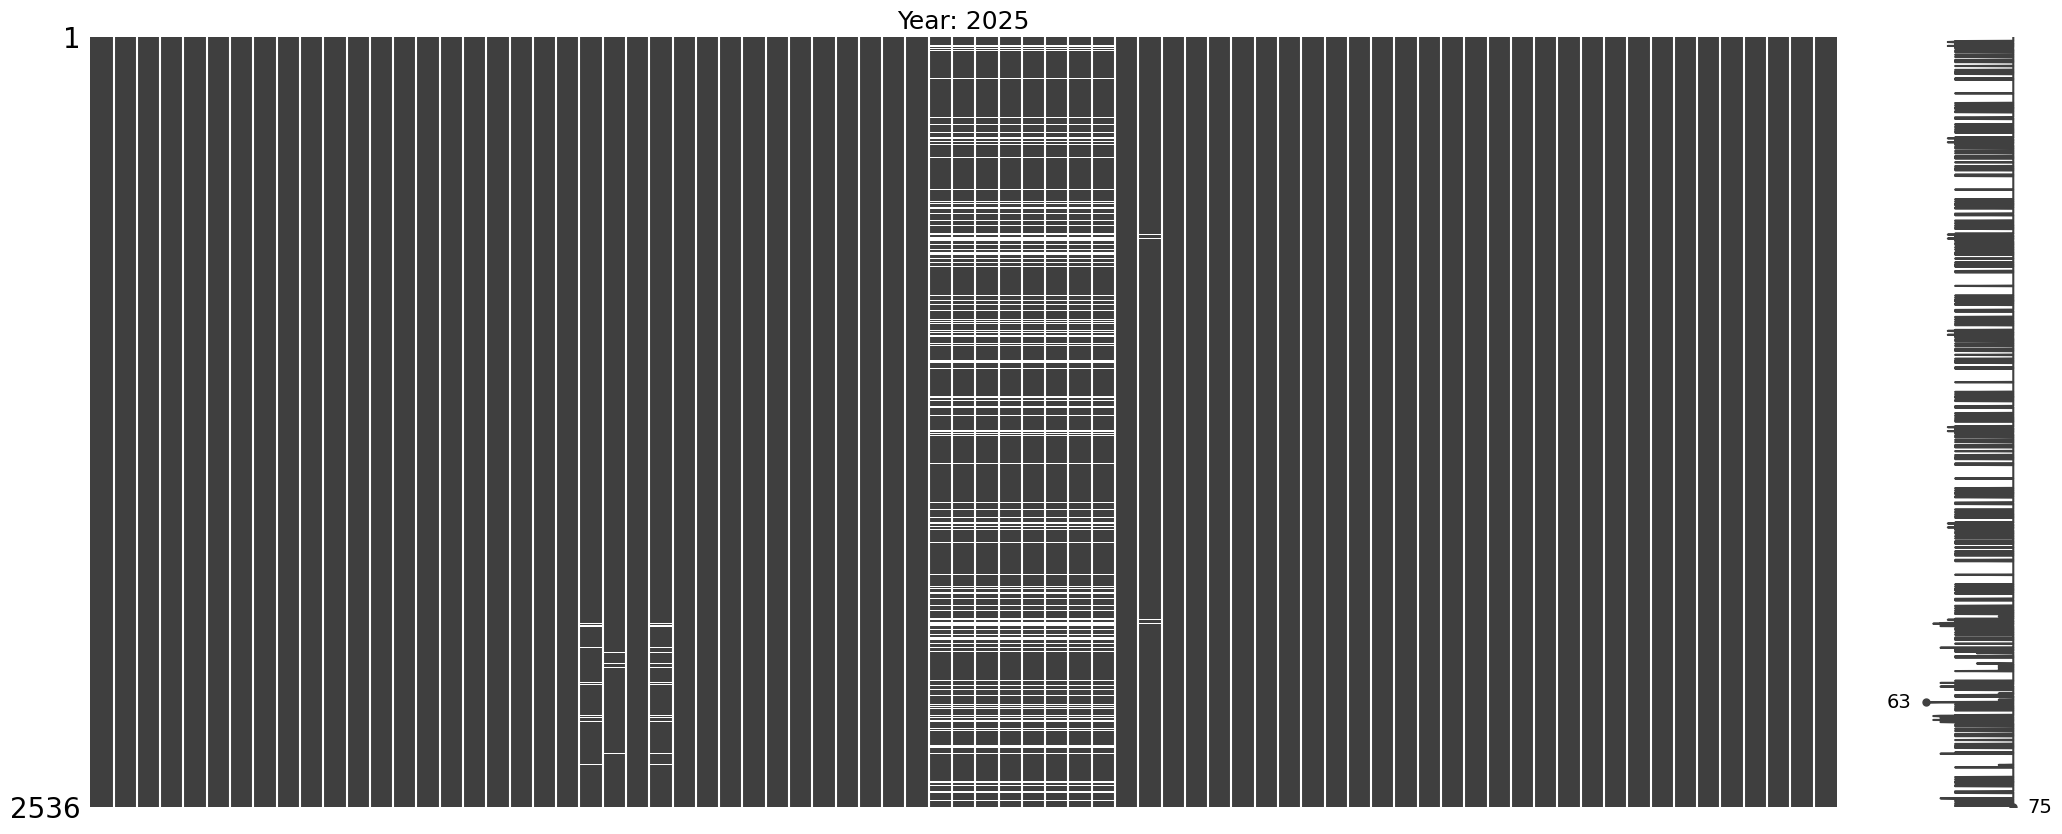

In [57]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [58]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2025-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2025,1,0.228613,-0.128800,-0.339775,0.128800,0.235684,-0.126217,-0.337048,0.126217,0.024453,0.023984,0.021800,0.023984,32.466860,19.064044,0.005527,25.718244,0.500,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2024,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,17.011333,37.255333,0.171333,0.171333,29.8125,20.625,64.453125,350.446144,48.0,16.0,32.0,27.666667,28.833333,33.833333,26.666667,598.0,236.0,0.0,129.172164,568.0,1.0,29.0,237.0
1,2025-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2025,1,0.228112,-0.152122,-0.314715,0.152122,0.226544,-0.148953,-0.316381,0.148953,0.018588,0.017084,0.013574,0.017084,33.346866,19.336222,0.001813,26.288349,0.500,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2024,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.961429,38.105238,0.056190,0.056190,30.6250,20.750,62.878788,356.320482,49.0,16.0,33.0,28.666667,29.666667,34.500000,27.166667,564.0,220.0,0.0,125.393689,521.0,0.0,43.0,220.0
2,2025-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2025,1,0.217678,-0.121785,-0.326881,0.121785,0.219530,-0.117612,-0.334587,0.117612,0.017830,0.014757,0.010896,0.014757,32.297742,19.414833,0.013226,25.811000,0.500,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2024,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.740000,36.850000,0.410000,0.410000,29.4375,19.125,59.765625,358.007881,47.0,15.0,32.0,27.500000,28.333333,33.500000,26.333333,590.0,226.0,0.0,129.675717,562.0,1.0,27.0,419.0
3,2025-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2025,1,0.240727,-0.127691,-0.327832,0.127691,0.245421,-0.126230,-0.330774,0.126230,0.017786,0.014073,0.014566,0.014073,31.538280,18.967889,0.002043,25.212778,0.500,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2024,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.280000,36.190000,0.063333,0.063333,29.5000,19.000,63.333333,328.416112,46.0,16.0,30.0,27.666667,28.666667,33.333333,26.500000,614.0,230.0,0.0,127.069696,576.0,0.0,38.0,230.0
4,2025-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2025,1,0.226639,-0.112302,-0.340948,0.112302,0.227393,-0.115807,-0.333396,0.115807,0.027435,0.024860,0.021228,0.024860,32.709274,19.470833,0.007944,26.044292,0.500,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2024,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,16.627500,37.350000,0.246250,0.246250,29.8125,20.625,62.500000,329.434038,48.0,15.0,33.0,28.166667,29.000000,33.500000,26.666667,613.0,233.0,0.0,126.489888,575.0,0.0,38.0,233.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [59]:
dataset[dataset.select_dtypes(include='float').columns] = dataset.select_dtypes(include='float').round(6)

rainfall_cols = [col for col in dataset.columns if 'rainfall' in col]
dataset[rainfall_cols] = dataset[rainfall_cols].round(4)

lst_cols = [col for col in dataset.columns if 'lst' in col]
dataset[lst_cols] = dataset[lst_cols].round(2)

bio_cols = [col for col in dataset.columns if 'bio' in col]
dataset[bio_cols] = dataset[bio_cols].round(2)

geo_cols += [f"{col}_std" for col in geo_cols]
dataset[geo_cols] = dataset[geo_cols].round(2)

dataset[mode_cols] = dataset[mode_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')



In [60]:
dataset.shape

(2536, 75)

In [61]:
new_order = ['dt_placement',
             'year',
             'month',
             'year_lc',
             'month_sin',
             'month_cos',
             'GID0',
             'GID1',
             'GID2',
             'GID3',
             'x',
             'y',
             'ndvi',
             'ndmi',
             'ndwi',
             'ndbi',
             'ndvi_mean',
             'ndmi_mean',
             'ndwi_mean',
             'ndbi_mean',
             'ndvi_std',
             'ndmi_std',
             'ndwi_std',
             'ndbi_std',
             'lst',
             'lst_day',
             'lst_night',
             'monthly_lst_min',
             'monthly_lst_max',
             'rainfall',
             'rainfall_acc',
             'monthly_rainfall_acc',
             'distance_to_coast', 
             'distance_to_river', 
             'slope_mean_1km',
             'aspect_mean_200m', 
             'elevation_mean_1km', 
             'hillshade_mean_1km',
             'fs_area_1km', 
             'flow_accu_200m', 
             'distance_to_coast_std',
             'distance_to_river_std', 
             'slope_mean_1km_std', 
             'aspect_mean_200m_std',
             'elevation_mean_1km_std', 
             'hillshade_mean_1km_std', 
             'fs_area_1km_std',
             'flow_accu_200m_std', 
             'lc_prop1', 
             'lc_prop2', 
             'lc_prop3', 
             'lc_type1',
             'lc_type2', 
             'lc_type3', 
             'lc_type4', 
             'lc_type5',
             'bio1',
             'bio2',
             'bio3',
             'bio4',
             'bio5',
             'bio6',
             'bio7',
             'bio8',
             'bio9',
             'bio10',
             'bio11',
             'bio12',
             'bio13',
             'bio14',
             'bio15',
             'bio16',
             'bio17',
             'bio18',
             'bio19']

In [62]:
dataset = dataset[new_order]

In [63]:
dataset.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.228613,-0.128800,-0.339775,0.128800,0.235684,-0.126217,-0.337048,0.126217,0.024453,0.023984,0.021800,0.023984,25.72,32.47,19.06,17.01,37.26,0.0055,0.1713,0.1713,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36,30,12,12,1,6,7,29.81,20.62,64.45,350.45,48.0,16.0,32.0,27.67,28.83,33.83,26.67,598.0,236.0,0.0,129.17,568.0,1.0,29.0,237.0
1,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.228112,-0.152122,-0.314715,0.152122,0.226544,-0.148953,-0.316381,0.148953,0.018588,0.017084,0.013574,0.017084,26.29,33.35,19.34,16.96,38.11,0.0018,0.0562,0.0562,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36,30,12,12,1,6,7,30.62,20.75,62.88,356.32,49.0,16.0,33.0,28.67,29.67,34.50,27.17,564.0,220.0,0.0,125.39,521.0,0.0,43.0,220.0
2,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.217678,-0.121785,-0.326881,0.121785,0.219530,-0.117612,-0.334587,0.117612,0.017830,0.014757,0.010896,0.014757,25.81,32.30,19.41,16.74,36.85,0.0132,0.4100,0.4100,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36,30,12,12,1,6,7,29.44,19.12,59.77,358.01,47.0,15.0,32.0,27.50,28.33,33.50,26.33,590.0,226.0,0.0,129.68,562.0,1.0,27.0,419.0
3,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.240727,-0.127691,-0.327832,0.127691,0.245421,-0.126230,-0.330774,0.126230,0.017786,0.014073,0.014566,0.014073,25.21,31.54,18.97,16.28,36.19,0.0020,0.0633,0.0633,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36,30,12,12,1,6,7,29.50,19.00,63.33,328.42,46.0,16.0,30.0,27.67,28.67,33.33,26.50,614.0,230.0,0.0,127.07,576.0,0.0,38.0,230.0
4,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.226639,-0.112302,-0.340948,0.112302,0.227393,-0.115807,-0.333396,0.115807,0.027435,0.024860,0.021228,0.024860,26.04,32.71,19.47,16.63,37.35,0.0079,0.2462,0.2462,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36,30,12,12,1,6,7,29.81,20.62,62.50,329.43,48.0,15.0,33.0,28.17,29.00,33.50,26.67,613.0,233.0,0.0,126.49,575.0,0.0,38.0,233.0


In [64]:
dataset.shape

(2536, 75)

In [65]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2536 entries, 0 to 2535
Data columns (total 75 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            2536 non-null   period[M]
 1   year                    2536 non-null   int32    
 2   month                   2536 non-null   int32    
 3   year_lc                 2536 non-null   int32    
 4   month_sin               2536 non-null   float64  
 5   month_cos               2536 non-null   float64  
 6   GID0                    2536 non-null   object   
 7   GID1                    2536 non-null   object   
 8   GID2                    2536 non-null   object   
 9   GID3                    2536 non-null   object   
 10  x                       2536 non-null   float64  
 11  y                       2536 non-null   float64  
 12  ndvi                    2535 non-null   float64  
 13  ndmi                    2535 non-null   float64  
 14  ndwi    

In [ ]:
#dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_grouped.csv', index=False, encoding=enc)

In [66]:
dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_08_grouped.csv', index=False, encoding=enc)